In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, FancyArrowPatch

We first generate the illustration for the exact one-sided circularised NUTS on the circle orbit.

1. Continuous case (when the tuning parameter distribution is continuous uniform, for exact flow).

2. Discrete case (when the tuning parameter distribution is discrete uniform, for leapfrog flow).

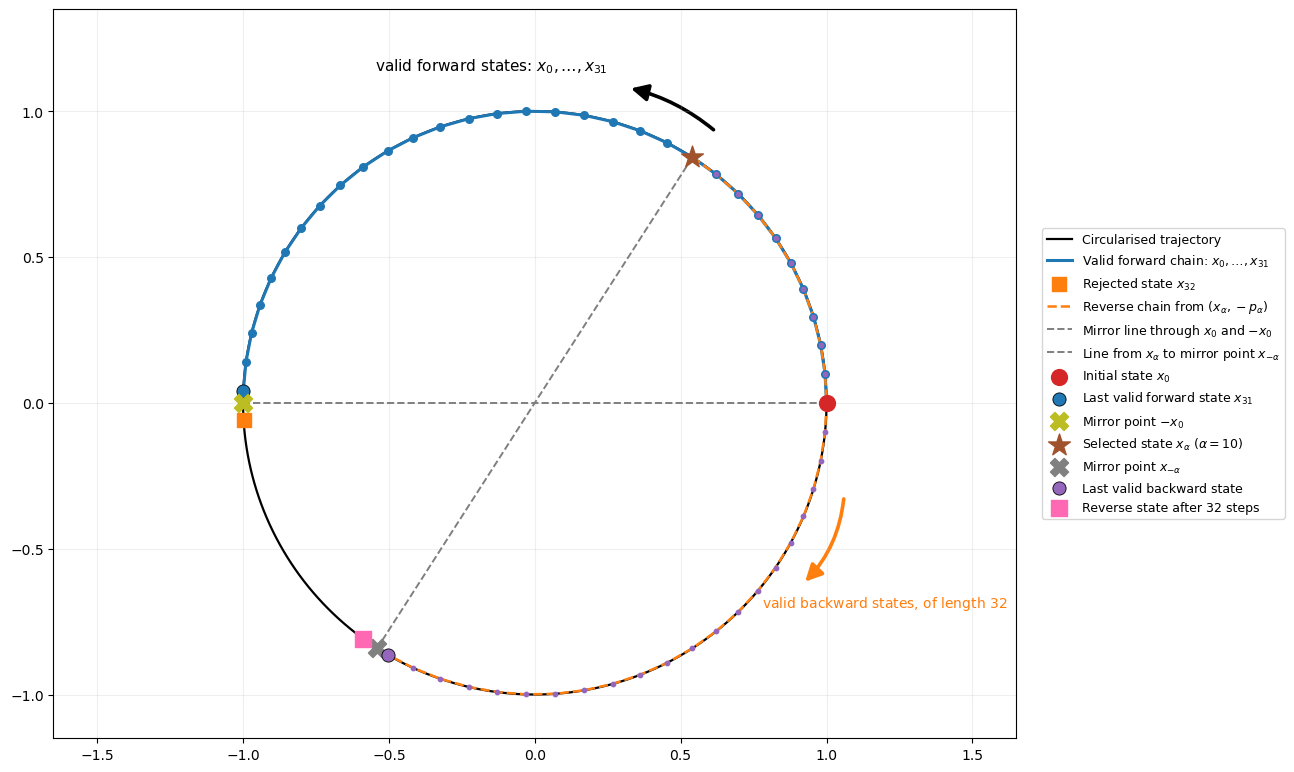

In [ ]:
# Discrete-time exact Hamiltonian flow for a 2D isotropic Gaussian target illustration

# ============================================================
# Parameters
# ============================================================
epsilon = 0.1
sigma = 1.0
radius = 1.0

tau = int(np.ceil(np.pi * sigma / epsilon))   # tau = 32
k_star = tau - 1                              # k_star = 31
alpha = 10

# ============================================================
# Forward trajectory
# ============================================================
forward_indices = np.arange(tau + 1)
forward_angles = forward_indices * epsilon / sigma

xf = radius * np.cos(forward_angles)
yf = radius * np.sin(forward_angles)

# ============================================================
# Selected state x_alpha and its mirror point
# ============================================================
theta_alpha = alpha * epsilon / sigma

x_alpha = np.array([
    radius * np.cos(theta_alpha),
    radius * np.sin(theta_alpha),
])

theta_mirror_alpha = theta_alpha + np.pi
x_mirror_alpha = np.array([
    radius * np.cos(theta_mirror_alpha),
    radius * np.sin(theta_mirror_alpha),
])

# ============================================================
# Reverse chain from (x_alpha, -p_alpha)
# ============================================================
reverse_indices = np.arange(tau + 1)
reverse_angles = theta_alpha - reverse_indices * epsilon / sigma

xr = radius * np.cos(reverse_angles)
yr = radius * np.sin(reverse_angles)

# Reverse state after 32 reverse steps
x_reverse_32 = np.array([xr[tau], yr[tau]])

# Mirror point of x0
mirror_x0 = np.array([-radius, 0.0])

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Full circular trajectory
theta = np.linspace(0, 2 * np.pi, 1000)
circle_line, = ax.plot(
    radius * np.cos(theta),
    radius * np.sin(theta),
    linewidth=1.6,
    color="black",
    label="Circularised trajectory",
)

# ============================================================
# Forward chain
# ============================================================
forward_line, = ax.plot(
    xf[:k_star + 1],
    yf[:k_star + 1],
    linewidth=2.2,
    color="tab:blue",
    label=r"Valid forward chain: $x_0,\ldots,x_{31}$",
)

ax.scatter(
    xf[:k_star + 1],
    yf[:k_star + 1],
    s=30,
    color="tab:blue",
    zorder=3,
)

# Rejected state x32 -> square
rejected_pt = ax.scatter(
    [xf[tau]],
    [yf[tau]],
    marker="s",
    s=110,
    color="tab:orange",
    zorder=8,
    label=r"Rejected state $x_{32}$",
)

# ============================================================
# Reverse chain
# ============================================================
reverse_line, = ax.plot(
    xr[:tau + 1],
    yr[:tau + 1],
    linestyle="--",
    linewidth=1.8,
    color="tab:orange",
    label=r"Reverse chain from $(x_\alpha,-p_\alpha)$",
)

ax.scatter(
    xr[:k_star + 1],
    yr[:k_star + 1],
    s=10,
    color="tab:purple",
    zorder=4,
)

# ============================================================
# Mirror / connecting lines
# ============================================================
# Diameter from x0 to -x0
mirror_x0_line, = ax.plot(
    [xf[0], mirror_x0[0]],
    [yf[0], mirror_x0[1]],
    linestyle="--",
    linewidth=1.4,
    color="tab:gray",
    label=r"Mirror line through $x_0$ and $-x_0$",
)

# Red dashed line from x_alpha to mirror point x_{-\alpha}
mirror_alpha_line, = ax.plot(
    [x_alpha[0], x_mirror_alpha[0]],
    [x_alpha[1], x_mirror_alpha[1]],
    linestyle="--",
    linewidth=1.4,
    color="tab:gray",
    label=r"Line from $x_\alpha$ to mirror point $x_{-\alpha}$",
)

# ============================================================
# Special states
# ============================================================
x0_pt = ax.scatter(
    [xf[0]],
    [yf[0]],
    s=130,
    color="tab:red",
    zorder=8,
    label=r"Initial state $x_0$",
)

x31_pt = ax.scatter(
    [xf[k_star]],
    [yf[k_star]],
    s=90,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
    zorder=8,
    label=r"Last valid forward state $x_{31}$",
)

# mirror point of x0 -> cross
mirror_x0_pt = ax.scatter(
    [mirror_x0[0]],
    [mirror_x0[1]],
    s=170,
    marker="X",
    color="tab:olive",
    zorder=8,
    label=r"Mirror point $-x_0$",
)

xalpha_pt = ax.scatter(
    [x_alpha[0]],
    [x_alpha[1]],
    s=270,
    marker="*",
    color="sienna",
    zorder=9,
    label=rf"Selected state $x_\alpha$ ($\alpha={alpha}$)",
)

mirror_alpha_pt = ax.scatter(
    [x_mirror_alpha[0]],
    [x_mirror_alpha[1]],
    s=170,
    marker="X",
    color="gray",
    zorder=8,
    label=r"Mirror point $x_{-\alpha}$",
)

reverse31_pt = ax.scatter(
    [xr[k_star]],
    [yr[k_star]],
    s=90,
    color="tab:purple",
    edgecolor="black",
    linewidth=0.6,
    zorder=8,
    label=r"Last valid backward state",
)

reverse32_pt = ax.scatter(
    [x_reverse_32[0]],
    [x_reverse_32[1]],
    s=125,
    marker="s",
    color="hotpink",
    zorder=9,
    label=r"Reverse state after 32 steps",
)

# ============================================================
# Small text label kept on top
# ============================================================
ax.text(
    -0.15, 1.14,
    r"valid forward states: $x_0,\ldots,x_{31}$",
    fontsize=11,
    ha="center"
)

# ============================================================
# Direction arrows
# ============================================================
forward_arrow = FancyArrowPatch(
    (0.62, 0.93),
    (0.32, 1.08),
    connectionstyle="arc3,rad=0.12",
    arrowstyle="-|>",
    mutation_scale=25,
    linewidth=2.6,
    color="black",
)
ax.add_patch(forward_arrow)

reverse_arrow = FancyArrowPatch(
    (1.06, -0.32),
    (0.92, -0.62),
    connectionstyle="arc3,rad=-0.18",
    arrowstyle="-|>",
    mutation_scale=25,
    linewidth=2.6,
    color="tab:orange",
)
ax.add_patch(reverse_arrow)

ax.text(
    1.2, -0.7,
    r"valid backward states, of length $32$",
    fontsize=10,
    color="tab:orange",
    ha="center"
)

# ============================================================
# Axes / formatting
# ============================================================
ax.set_aspect("equal")
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.15, 1.35)

# ax.set_title(
#     "One-sided circularised NUTS / GIST on a discrete grid of the exact Hamiltonian flow",
#     fontsize=14,
# )

ax.grid(alpha=0.2)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

Then we sample and check that the exact one-sided circularised NUTS DOES improve the mixing.

## Continuous version (exact flow)

In [ ]:
from scipy.optimize import brentq
from typing import Optional

class ordinary_GIST_NUTS_continuous:
    """
    Ordinary one-sided exact-flow GIST sampler for a Gaussian target.

    Target
    ------
        x ~ N(mean, covariance)

    Momentum
    --------
        p ~ N(0, I_d)

    At every transition:

    1. Refresh p ~ N(0, I_d).
    2. Compute the first one-sided U-turn time

           tau_1 = tau(x, p).

    3. Sample

           alpha ~ Uniform(0, tau_1).

    4. Follow the exact Hamiltonian flow for time alpha:

           (x_alpha, p_alpha) = phi_alpha(x, p).

    5. Apply momentum reversal:

           (x_proposed, p_proposed) = (x_alpha, -p_alpha).

    6. Compute

           tau_2 = tau(x_proposed, p_proposed).

    7. Accept with probability

           min(1, tau_1 / tau_2) * 1{tau_2 >= alpha}.

    Parameters
    ----------
    covariance:
        Symmetric positive-definite Gaussian covariance matrix.

    mean:
        Gaussian mean. Defaults to zero.

    uturn_condition:
        Either:

        "distance":
            Stops at the first positive root of

                (x_t - x_0)^T p_t = 0.

            This corresponds to the distance-based criterion in
            Equation (6) of the GIST paper.

        "angle":
            Stops at the first positive root of

                p_0^T p_t = 0.

            This corresponds to the angle-based criterion in
            Equation (5) of the GIST paper.

    scan_step:
        Grid spacing used only to bracket the first root before
        applying Brent's root-finding method. It is not an HMC
        integration step, because the Hamiltonian flow is exact.

    max_time:
        Maximum time searched for a U-turn.

    root_tolerance:
        Numerical tolerance used by the root solver.

    seed:
        Random-number-generator seed.
    """

    def __init__(
        self,
        covariance: np.ndarray,
        mean: Optional[np.ndarray] = None,
        uturn_condition: str = "distance",
        scan_step: Optional[float] = None,
        max_time: Optional[float] = None,
        root_tolerance: float = 1e-12,
        seed: Optional[int] = None,
    ) -> None:

        covariance = np.asarray(covariance, dtype=float)  # convert to float array

        if covariance.ndim == 0:
            covariance = covariance.reshape(1, 1)

        if (
            covariance.ndim != 2
            or covariance.shape[0] != covariance.shape[1]
        ):
            raise ValueError(
                "covariance must be a square matrix."
            )

        if not np.allclose(
            covariance,
            covariance.T,
            atol=1e-12,
            rtol=1e-12,
        ):
            raise ValueError(
                "covariance must be symmetric."
            )

        eigenvalues, eigenvectors = np.linalg.eigh(covariance)

        if np.any(eigenvalues <= 0):
            raise ValueError(
                "covariance must be positive definite."
            )

        self.covariance = covariance
        self.dimension = covariance.shape[0]

        if mean is None:
            self.mean = np.zeros(self.dimension)  # default to zero mean
        else:
            self.mean = np.asarray(mean, dtype=float)

            if self.mean.shape != (self.dimension,):
                raise ValueError(
                    f"mean must have shape ({self.dimension},)."
                )

        if uturn_condition not in {"distance", "angle"}:
            raise ValueError(
                "uturn_condition must be either "
                "'distance' or 'angle'."
            )  # ensure the uturn_condition is either "distance" or "angle"

        self.uturn_condition = uturn_condition

        # Sigma = Q diag(sigma_i^2) Q^T
        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors
        self.standard_deviations = np.sqrt(eigenvalues)

        self.root_tolerance = float(root_tolerance)

        if self.root_tolerance <= 0:
            raise ValueError(
                "root_tolerance must be positive."
            )

        # Resolve the fastest oscillation sufficiently finely.
        if scan_step is None:
            self.scan_step = (
                np.pi
                * np.min(self.standard_deviations)
                / 64.0
            )
        else:
            self.scan_step = float(scan_step)

        if self.scan_step <= 0:
            raise ValueError(
                "scan_step must be positive."
            )

        if max_time is None:
            self.max_time = (
                10.0
                * np.pi
                * np.max(self.standard_deviations)
            )
        else:
            self.max_time = float(max_time)

        if self.max_time <= 0:
            raise ValueError(
                "max_time must be positive."
            )

        self.rng = np.random.default_rng(seed)

    # ========================================================
    # Validation
    # ========================================================

    def _validate_vector(
        self,
        value: np.ndarray,
        name: str,
    ) -> np.ndarray:
        value = np.asarray(value, dtype=float)

        if value.shape != (self.dimension,):
            raise ValueError(
                f"{name} must have shape "
                f"({self.dimension},)."
            )

        if not np.all(np.isfinite(value)):
            raise ValueError(
                f"{name} contains non-finite values."
            )

        return value

    # ========================================================
    # Exact Gaussian Hamiltonian flow
    # ========================================================

    def exact_flow(
        self,
        x: np.ndarray,
        p: np.ndarray,
        time: float,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Evaluate the exact Hamiltonian flow phi_time(x, p).

        For

            U(x) = 1/2 (x-mu)^T Sigma^{-1}(x-mu),

        and identity mass matrix, diagonalising

            Sigma = Q diag(sigma_i^2) Q^T

        gives the componentwise exact solution

            q_i(t)
              = cos(t/sigma_i) q_i(0)
                + sigma_i sin(t/sigma_i) p_i(0),

            p_i(t)
              = -sin(t/sigma_i)/sigma_i q_i(0)
                + cos(t/sigma_i) p_i(0).
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        time = float(time)

        if not np.isfinite(time):
            raise ValueError(
                "time must be finite."
            )

        # Transform to the covariance eigenbasis.
        q_initial = (
            self.eigenvectors.T
            @ (x - self.mean)
        )
        p_initial = (
            self.eigenvectors.T
            @ p
        )

        phase = time / self.standard_deviations

        cosine = np.cos(phase)
        sine = np.sin(phase)

        q_time = (
            cosine * q_initial
            + self.standard_deviations
            * sine
            * p_initial
        )

        p_time = (
            -sine
            / self.standard_deviations
            * q_initial
            + cosine
            * p_initial
        )

        x_time = (
            self.mean
            + self.eigenvectors @ q_time
        )

        p_time = self.eigenvectors @ p_time

        return x_time, p_time

    # ========================================================
    # Hamiltonian
    # ========================================================

    def hamiltonian(
        self,
        x: np.ndarray,
        p: np.ndarray,
    ) -> float:
        """
        Return H(x,p) = U(x) + ||p||^2 / 2.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        centred = x - self.mean
        transformed = self.eigenvectors.T @ centred

        potential = 0.5 * np.sum(
            transformed**2 / self.eigenvalues
        )

        kinetic = 0.5 * np.dot(p, p)

        return float(potential + kinetic)

    # ========================================================
    # U-turn functions
    # ========================================================

    def _uturn_function(
        self,
        time: float,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> float:
        """
        Scalar function whose first positive zero defines tau.
        """
        x_time, p_time = self.exact_flow(
            x_initial,
            p_initial,
            time,
        )

        if self.uturn_condition == "angle":
            # Equation (5):
            # p_0^T p_t <= 0
            return float(
                np.dot(p_initial, p_time)
            )

        # Equation (6):
        #
        # Gamma'(t)
        #   = 2 (x_t-x_0)^T p_t.
        #
        # The factor 2 does not affect the root.
        return float(
            np.dot(
                x_time - x_initial,
                p_time,
            )
        )

    # ========================================================
    # First U-turn time
    # ========================================================

    def stopping_time(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> float:
        """
        Find the first positive U-turn time tau(x_initial,p_initial).

        The exact flow is evaluated on a fine grid only to bracket
        the first sign change. Brent's method then locates the root.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )
        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        if np.linalg.norm(p_initial) <= self.root_tolerance:
            raise ValueError(
                "The supplied momentum is numerically zero; "
                "the stopping time is degenerate."
            )

        if self.uturn_condition == "angle":
            previous_time = 0.0

            previous_value = self._uturn_function(
                previous_time,
                x_initial,
                p_initial,
            )

        else:
            # For the distance condition, the function is exactly
            # zero at t=0. Start just to the right of zero, where
            #
            # (x_t-x_0)^T p_t
            #
            # is positive for nonzero momentum.
            previous_time = max(
                10.0 * self.root_tolerance,
                1e-6 * self.scan_step,
            )

            previous_value = self._uturn_function(
                previous_time,
                x_initial,
                p_initial,
            )

            if previous_value <= 0:
                raise RuntimeError(
                    "Could not establish a positive initial "
                    "distance derivative. Try increasing "
                    "root_tolerance or scan_step."
                )

        current_time = (
            previous_time + self.scan_step
        )

        while current_time <= (
            self.max_time + self.root_tolerance
        ):
            current_value = self._uturn_function(
                current_time,
                x_initial,
                p_initial,
            )

            if current_value <= 0:
                if abs(current_value) <= self.root_tolerance:
                    return float(current_time)

                root = brentq(
                    lambda t: self._uturn_function(
                        t,
                        x_initial,
                        p_initial,
                    ),
                    previous_time,
                    current_time,
                    xtol=self.root_tolerance,
                    rtol=4.0 * np.finfo(float).eps,
                )

                return float(root)

            previous_time = current_time
            previous_value = current_value
            current_time += self.scan_step

        raise RuntimeError(
            "No U-turn was found before max_time. "
            "Increase max_time or reduce scan_step."
        )

    # ========================================================
    # One GIST transition
    # ========================================================

    def transition(
        self,
        x_current: np.ndarray,
    ) -> tuple[np.ndarray, dict]:
        """
        Perform one ordinary exact one-sided GIST transition.
        """
        x_current = self._validate_vector(
            x_current,
            "x_current",
        )

        # Complete momentum refreshment.
        p_initial = self.rng.normal(
            size=self.dimension
        )

        tau_1 = self.stopping_time(
            x_current,
            p_initial,
        )

        # Gibbs refreshment of the path length.
        alpha = self.rng.uniform(
            low=0.0,
            high=tau_1,
        )

        x_alpha, p_alpha = self.exact_flow(
            x_current,
            p_initial,
            alpha,
        )

        # Apply the momentum-flip involution S.
        x_proposed = x_alpha
        p_proposed = -p_alpha

        tau_2 = self.stopping_time(
            x_proposed,
            p_proposed,
        )

        # Exact-flow GIST acceptance probability:
        #
        # min(1, tau_1/tau_2) 1{tau_2 >= alpha}.
        if tau_2 + self.root_tolerance < alpha:
            acceptance_probability = 0.0
        else:
            acceptance_probability = min(
                1.0,
                tau_1 / tau_2,
            )

        accepted = bool(
            self.rng.uniform()
            < acceptance_probability
        )

        if accepted:
            x_next = x_proposed.copy()
        else:
            x_next = x_current.copy()

        initial_energy = self.hamiltonian(
            x_current,
            p_initial,
        )

        proposed_energy = self.hamiltonian(
            x_alpha,
            p_alpha,
        )

        information = {
            "momentum": p_initial.copy(),
            "proposal": x_proposed.copy(),
            "proposal_momentum": p_proposed.copy(),
            "tau_1": tau_1,
            "alpha": alpha,
            "tau_2": tau_2,
            "acceptance_probability": (
                acceptance_probability
            ),
            "accepted": accepted,
            "energy_error": (
                proposed_energy - initial_energy
            ),
        }

        return x_next, information

    # ========================================================
    # Generate a Markov chain
    # ========================================================

    def sample(
        self,
        initial_position: np.ndarray,
        n_samples: int,
        burn_in: int = 0,
        thin: int = 1,
    ) -> tuple[np.ndarray, dict]:
        """
        Generate samples from the ordinary exact GIST chain.
        """
        if n_samples <= 0:
            raise ValueError(
                "n_samples must be positive."
            )

        if burn_in < 0:
            raise ValueError(
                "burn_in must be nonnegative."
            )

        if thin <= 0:
            raise ValueError(
                "thin must be positive."
            )

        current = self._validate_vector(
            initial_position,
            "initial_position",
        ).copy()

        total_transitions = (
            burn_in + n_samples * thin
        )

        samples = np.empty(
            (n_samples, self.dimension)
        )

        accepted = np.empty(
            total_transitions,
            dtype=bool,
        )

        acceptance_probabilities = np.empty(
            total_transitions
        )

        tau_1_values = np.empty(
            total_transitions
        )

        tau_2_values = np.empty(
            total_transitions
        )

        alpha_values = np.empty(
            total_transitions
        )

        energy_errors = np.empty(
            total_transitions
        )

        sample_index = 0

        for iteration in range(total_transitions):
            current, information = self.transition(
                current
            )

            accepted[iteration] = (
                information["accepted"]
            )

            acceptance_probabilities[iteration] = (
                information[
                    "acceptance_probability"
                ]
            )

            tau_1_values[iteration] = (
                information["tau_1"]
            )

            tau_2_values[iteration] = (
                information["tau_2"]
            )

            alpha_values[iteration] = (
                information["alpha"]
            )

            energy_errors[iteration] = (
                information["energy_error"]
            )

            if iteration >= burn_in:
                post_burn_iteration = (
                    iteration - burn_in
                )

                if post_burn_iteration % thin == 0:
                    samples[sample_index] = current
                    sample_index += 1

        diagnostics = {
            "accepted": accepted,
            "acceptance_probability": (
                acceptance_probabilities
            ),
            "tau_1": tau_1_values,
            "tau_2": tau_2_values,
            "alpha": alpha_values,
            "energy_error": energy_errors,
            "acceptance_rate": float(
                np.mean(accepted)
            ),
            "mean_acceptance_probability": float(
                np.mean(
                    acceptance_probabilities
                )
            ),
        }

        return samples, diagnostics


# A simple trial
Sigma = np.array([
    [1.0, 0],
    [0, 1.0],
])

sampler = ordinary_GIST_NUTS_continuous(
    covariance=Sigma,
    mean=np.zeros(2),
    uturn_condition="distance",
    seed=0,
)

samples, diagnostics = sampler.sample(
    initial_position=np.array([2.0, -1.0]),
    n_samples=5000,
    burn_in=1000,
)

print(
    "Acceptance rate:",
    diagnostics["acceptance_rate"],
)

print(
    "Maximum absolute energy error:",
    np.max(
        np.abs(diagnostics["energy_error"])
    ),
)

## Discrete sampling but still based on the exact flow

In [11]:
from __future__ import annotations

from typing import Optional


class ordinary_GIST_NUTS:
    """
    Ordinary one-sided discrete-grid GIST sampler for an isotropic
    Gaussian target using the exact Hamiltonian flow.

    Target
    ------
        x ~ N(mean, sigma^2 I_d)

    Momentum
    --------
        p ~ N(0, I_d)

    The exact Hamiltonian flow is observed only at times

        t_k = k * epsilon.

    Thus, epsilon is an exact-flow observation spacing rather than
    a leapfrog integration step size.

    U-turn criterion
    ----------------
    The stopping index is

        tau(x0, p0)
            = min{k >= 1 : (x_k - x0)^T p_k <= 0}.

    Selection rules
    ---------------
    selection="paper":
        Sample

            L ~ Uniform{1, ..., tau}.

        This follows the positive-integer uniform construction used
        in Section 5.2.1 of the GIST paper.

    selection="before_uturn":
        Sample

            L ~ Uniform{0, ..., tau - 1}.

        This excludes the state that triggers the U-turn and matches
        the convention

            x_0, ..., x_{tau-1} valid,
            x_tau rejected.

        Including L=0 ensures that the conditional support is never
        empty. Restricting instead to {1, ..., tau-1} is problematic
        for ordinary NUTS because tau may equal 1.

    Parameters
    ----------
    dimension:
        Dimension d of the target.

    sigma:
        Marginal standard deviation of the isotropic Gaussian.

    epsilon:
        Grid spacing used to observe the exact flow.

    mean:
        Mean vector. Defaults to zero.

    selection:
        Either "paper" or "before_uturn".

    max_steps:
        Maximum number of exact-flow grid points searched for a U-turn.

    uturn_tolerance:
        Stop when the U-turn score is at most this value.
        Use 0.0 for the exact <= 0 criterion.

    seed:
        Random-number-generator seed.
    """

    def __init__(
        self,
        dimension: int,
        sigma: float = 1.0,
        epsilon: float = 0.1,
        mean: Optional[np.ndarray] = None,
        selection: str = "before_uturn",
        max_steps: int = 100_000,
        uturn_tolerance: float = 0.0,
        seed: Optional[int] = None,
    ) -> None:

        if (
            not isinstance(dimension, (int, np.integer))
            or dimension < 1
        ):
            raise ValueError(
                "dimension must be a positive integer."
            )

        if not np.isfinite(sigma) or sigma <= 0:
            raise ValueError(
                "sigma must be positive and finite."
            )

        if not np.isfinite(epsilon) or epsilon <= 0:
            raise ValueError(
                "epsilon must be positive and finite."
            )

        if not isinstance(max_steps, (int, np.integer)) or max_steps < 1:
            raise ValueError(
                "max_steps must be a positive integer."
            )

        if selection not in {
            "paper",
            "before_uturn",
        }:
            raise ValueError(
                "selection must be either "
                "'paper' or 'before_uturn'."
            )

        self.dimension = int(dimension)
        self.sigma = float(sigma)
        self.epsilon = float(epsilon)
        self.selection = selection
        self.max_steps = int(max_steps)
        self.uturn_tolerance = float(uturn_tolerance)

        if mean is None:
            self.mean = np.zeros(self.dimension)
        else:
            self.mean = np.asarray(mean, dtype=float)

            if self.mean.shape != (self.dimension,):
                raise ValueError(
                    f"mean must have shape ({self.dimension},)."
                )

            if not np.all(np.isfinite(self.mean)):
                raise ValueError(
                    "mean contains non-finite values."
                )

        self.rng = np.random.default_rng(seed)

    # ========================================================
    # Validation
    # ========================================================

    def _validate_vector(
        self,
        value: np.ndarray,
        name: str,
    ) -> np.ndarray:
        """Validate and return a d-dimensional vector."""
        value = np.asarray(value, dtype=float)

        if value.shape != (self.dimension,):
            raise ValueError(
                f"{name} must have shape ({self.dimension},)."
            )

        if not np.all(np.isfinite(value)):
            raise ValueError(
                f"{name} contains non-finite values."
            )

        return value

    # ========================================================
    # Exact isotropic Gaussian flow
    # ========================================================

    def exact_flow(
        self,
        x: np.ndarray,
        p: np.ndarray,
        n_steps: int,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Evaluate the exact flow at time n_steps * epsilon.

        For q = x - mean,

            q_k = cos(theta_k) q
                  + sigma sin(theta_k) p,

            p_k = cos(theta_k) p
                  - sin(theta_k) q / sigma,

        where theta_k = k epsilon / sigma.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        if (
            not isinstance(n_steps, (int, np.integer))
            or n_steps < 0
        ):
            raise ValueError(
                "n_steps must be a nonnegative integer."
            )

        angle = (
            int(n_steps)
            * self.epsilon
            / self.sigma
        )

        cosine = np.cos(angle)
        sine = np.sin(angle)

        centred = x - self.mean

        x_new = (
            self.mean
            + cosine * centred
            + self.sigma * sine * p
        )

        p_new = (
            cosine * p
            - (sine / self.sigma) * centred
        )

        return x_new, p_new

    # ========================================================
    # Exact trajectory
    # ========================================================

    def trajectory(
        self,
        x: np.ndarray,
        p: np.ndarray,
        n_steps: int,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Return all exact-flow states for k = 0, ..., n_steps.

        Returns
        -------
        positions:
            Array with shape (n_steps + 1, dimension).

        momenta:
            Array with shape (n_steps + 1, dimension).
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        if (
            not isinstance(n_steps, (int, np.integer))
            or n_steps < 0
        ):
            raise ValueError(
                "n_steps must be a nonnegative integer."
            )

        indices = np.arange(int(n_steps) + 1)
        angles = (
            indices
            * self.epsilon
            / self.sigma
        )

        cosine = np.cos(angles)[:, None]
        sine = np.sin(angles)[:, None]

        centred = x - self.mean

        positions = (
            self.mean[None, :]
            + cosine * centred[None, :]
            + self.sigma * sine * p[None, :]
        )

        momenta = (
            cosine * p[None, :]
            - (sine / self.sigma)
            * centred[None, :]
        )

        return positions, momenta

    # ========================================================
    # Hamiltonian
    # ========================================================

    def hamiltonian(
        self,
        x: np.ndarray,
        p: np.ndarray,
    ) -> float:
        """
        Compute

            H(x,p)
              = ||x-mean||^2 / (2 sigma^2)
                + ||p||^2 / 2.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        centred = x - self.mean

        potential = (
            0.5
            * np.dot(centred, centred)
            / self.sigma**2
        )

        kinetic = 0.5 * np.dot(p, p)

        return float(potential + kinetic)

    # ========================================================
    # Ordinary U-turn criterion
    # ========================================================

    def uturn_score(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
        step_index: int,
    ) -> float:
        """
        Compute the ordinary one-sided U-turn score

            (x_k - x_0)^T p_k.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )

        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        x_step, p_step = self.exact_flow(
            x_initial,
            p_initial,
            step_index,
        )

        return float(
            np.dot(
                x_step - x_initial,
                p_step,
            )
        )

    def stopping_index(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> int:
        """
        Return

            tau = min{k >= 1 :
                      (x_k-x_0)^T p_k <= tolerance}.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )

        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        for step_index in range(
            1,
            self.max_steps + 1,
        ):
            score = self.uturn_score(
                x_initial,
                p_initial,
                step_index,
            )

            if score <= self.uturn_tolerance:
                return step_index

        raise RuntimeError(
            "No U-turn was detected before max_steps. "
            "Increase max_steps or inspect epsilon."
        )

    # ========================================================
    # Candidate-index distribution
    # ========================================================

    def candidate_bounds(
        self,
        stopping_index: int,
    ) -> tuple[int, int]:
        """
        Return the inclusive lower and upper candidate indices.
        """
        if stopping_index < 1:
            raise ValueError(
                "stopping_index must be positive."
            )

        if self.selection == "paper":
            # L in {1, ..., tau}
            return 1, stopping_index

        # L in {0, ..., tau-1}
        return 0, stopping_index - 1

    # ========================================================
    # One transition
    # ========================================================

    def transition(
        self,
        x_current: np.ndarray,
        momentum: Optional[np.ndarray] = None,
        selected_index: Optional[int] = None,
    ) -> tuple[np.ndarray, dict]:
        """
        Perform one discrete exact-flow GIST transition.

        Optional momentum and selected_index arguments are useful
        for debugging and reproducing individual transitions.
        """
        x_current = self._validate_vector(
            x_current,
            "x_current",
        )

        # ----------------------------------------------------
        # Momentum refreshment
        # ----------------------------------------------------
        if momentum is None:
            p_initial = self.rng.normal(
                size=self.dimension
            )
        else:
            p_initial = self._validate_vector(
                momentum,
                "momentum",
            )

        # ----------------------------------------------------
        # Forward stopping index and candidate support
        # ----------------------------------------------------
        tau_forward = self.stopping_index(
            x_current,
            p_initial,
        )

        lower_forward, upper_forward = (
            self.candidate_bounds(tau_forward)
        )

        n_forward_candidates = (
            upper_forward
            - lower_forward
            + 1
        )

        # ----------------------------------------------------
        # Gibbs sample the discrete path index
        # ----------------------------------------------------
        if selected_index is None:
            path_index = int(
                self.rng.integers(
                    lower_forward,
                    upper_forward + 1,
                )
            )
        else:
            path_index = int(selected_index)

            if not (
                lower_forward
                <= path_index
                <= upper_forward
            ):
                raise ValueError(
                    "selected_index is outside the "
                    "forward candidate support."
                )

        # ----------------------------------------------------
        # Exact-flow proposal followed by momentum reversal
        # ----------------------------------------------------
        x_path, p_path = self.exact_flow(
            x_current,
            p_initial,
            path_index,
        )

        x_proposed = x_path.copy()
        p_proposed = -p_path

        # ----------------------------------------------------
        # Reverse stopping index
        # ----------------------------------------------------
        tau_reverse = self.stopping_index(
            x_proposed,
            p_proposed,
        )

        lower_reverse, upper_reverse = (
            self.candidate_bounds(tau_reverse)
        )

        n_reverse_candidates = (
            upper_reverse
            - lower_reverse
            + 1
        )

        # ----------------------------------------------------
        # Exact-flow energy difference
        # ----------------------------------------------------
        energy_initial = self.hamiltonian(
            x_current,
            p_initial,
        )

        energy_proposed = self.hamiltonian(
            x_proposed,
            p_proposed,
        )

        energy_error = (
            energy_proposed
            - energy_initial
        )

        # ----------------------------------------------------
        # GIST acceptance probability
        #
        # q(L | reverse) / q(L | forward)
        #   = n_forward / n_reverse,
        #
        # provided L belongs to the reverse support.
        # ----------------------------------------------------
        reverse_supports_index = (
            lower_reverse
            <= path_index
            <= upper_reverse
        )

        if not reverse_supports_index:
            acceptance_probability = 0.0
        else:
            log_acceptance_ratio = (
                -energy_error
                + np.log(n_forward_candidates)
                - np.log(n_reverse_candidates)
            )

            acceptance_probability = float(
                np.exp(
                    min(
                        0.0,
                        log_acceptance_ratio,
                    )
                )
            )

        accepted = bool(
            self.rng.uniform()
            < acceptance_probability
        )

        if accepted:
            x_next = x_proposed.copy()
        else:
            x_next = x_current.copy()

        information = {
            "accepted": accepted,
            "acceptance_probability": (
                acceptance_probability
            ),
            "momentum": p_initial.copy(),
            "selected_index": path_index,
            "proposal": x_proposed.copy(),
            "proposal_momentum": (
                p_proposed.copy()
            ),
            "tau_forward": tau_forward,
            "tau_reverse": tau_reverse,
            "forward_support": (
                lower_forward,
                upper_forward,
            ),
            "reverse_support": (
                lower_reverse,
                upper_reverse,
            ),
            "n_forward_candidates": (
                n_forward_candidates
            ),
            "n_reverse_candidates": (
                n_reverse_candidates
            ),
            "energy_error": float(energy_error),
        }

        return x_next, information

    # ========================================================
    # Generate a Markov chain
    # ========================================================

    def sample(
        self,
        initial_position: np.ndarray,
        n_samples: int,
        burn_in: int = 0,
        thin: int = 1,
    ) -> tuple[np.ndarray, dict]:
        """
        Generate samples from the discrete exact-flow GIST chain.
        """
        if (
            not isinstance(n_samples, (int, np.integer))
            or n_samples < 1
        ):
            raise ValueError(
                "n_samples must be a positive integer."
            )

        if (
            not isinstance(burn_in, (int, np.integer))
            or burn_in < 0
        ):
            raise ValueError(
                "burn_in must be a nonnegative integer."
            )

        if (
            not isinstance(thin, (int, np.integer))
            or thin < 1
        ):
            raise ValueError(
                "thin must be a positive integer."
            )

        current = self._validate_vector(
            initial_position,
            "initial_position",
        ).copy()

        total_transitions = (
            int(burn_in)
            + int(n_samples) * int(thin)
        )

        samples = np.empty(
            (int(n_samples), self.dimension)
        )

        accepted = np.empty(
            total_transitions,
            dtype=bool,
        )

        acceptance_probabilities = np.empty(
            total_transitions
        )

        selected_indices = np.empty(
            total_transitions,
            dtype=int,
        )

        tau_forward_values = np.empty(
            total_transitions,
            dtype=int,
        )

        tau_reverse_values = np.empty(
            total_transitions,
            dtype=int,
        )

        energy_errors = np.empty(
            total_transitions
        )

        sample_index = 0

        for iteration in range(total_transitions):
            current, information = self.transition(
                current
            )

            accepted[iteration] = (
                information["accepted"]
            )

            acceptance_probabilities[iteration] = (
                information[
                    "acceptance_probability"
                ]
            )

            selected_indices[iteration] = (
                information["selected_index"]
            )

            tau_forward_values[iteration] = (
                information["tau_forward"]
            )

            tau_reverse_values[iteration] = (
                information["tau_reverse"]
            )

            energy_errors[iteration] = (
                information["energy_error"]
            )

            if iteration >= burn_in:
                post_burn_iteration = (
                    iteration - burn_in
                )

                if post_burn_iteration % thin == 0:
                    samples[sample_index] = current
                    sample_index += 1

        diagnostics = {
            "accepted": accepted,
            "acceptance_probability": (
                acceptance_probabilities
            ),
            "selected_index": selected_indices,
            "tau_forward": tau_forward_values,
            "tau_reverse": tau_reverse_values,
            "energy_error": energy_errors,
            "acceptance_rate": float(
                np.mean(accepted)
            ),
            "mean_acceptance_probability": float(
                np.mean(
                    acceptance_probabilities
                )
            ),
            "mean_forward_stopping_index": float(
                np.mean(tau_forward_values)
            ),
            "mean_reverse_stopping_index": float(
                np.mean(tau_reverse_values)
            ),
        }

        return samples, diagnostics

In [12]:
sampler = ordinary_GIST_NUTS(
    dimension=2,
    sigma=1.0,
    epsilon=0.1,
    selection="before_uturn",
    seed=42,
)

samples, diagnostics = sampler.sample(
    initial_position=np.array([2.0, -1.0]),
    n_samples=10_000,
    burn_in=1_000,
)

print(
    "Acceptance rate:",
    diagnostics["acceptance_rate"],
)

print(
    "Sample mean:",
    samples.mean(axis=0),
)

print(
    "Sample variance:",
    samples.var(axis=0),
)

print(
    "Maximum energy error:",
    np.max(
        np.abs(diagnostics["energy_error"])
    ),
)

Acceptance rate: 0.6932727272727273
Sample mean: [0.00502427 0.00157745]
Sample variance: [0.98133067 0.98087756]
Maximum energy error: 2.6645352591003757e-15
